# 03. Model Fuzzy Sugeno

Notebook ini mengerjakan satu contoh kasus dengan metode Sugeno, yaitu mesin cuci otomatis yang menentukan kecepatan putar dari banyaknya pakaian dan tingkat kekotoran. Pembahasannya mengikuti urutan tahap sistem inferensi fuzzy, dari input sampai output.

Setelah menyelesaikan notebook ini, mahasiswa diharapkan mampu menjelaskan tahap sistem inferensi fuzzy, menghitung fuzzifikasi dua input, menghitung $\alpha$-predikat dan nilai $z$ setiap aturan Sugeno, serta menghitung output dengan rata-rata berbobot.

| Bagian | Isi |
|---|---|
| 3.1 | Sistem inferensi fuzzy |
| 3.2 | Contoh kasus mesin cuci otomatis |
| 3.3 | Tahap 1: fuzzifikasi |
| 3.4 | Tahap 2: inferensi |
| 3.5 | Tahap 3: defuzzifikasi |
| 3.6 | Seluruh tahap dalam satu fungsi |
| Latihan Soal | Tiga soal dengan kasus yang sama |

Notebook ini memakai fungsi keanggotaan linier dan segitiga dari Notebook 01, serta operator AND dari Notebook 01 bagian 1.7.

## Setup

Jalankan sel ini lebih dahulu. Sel ini sama dengan sel setup pada notebook lain. Fungsi keanggotaan diambil dari `membership.py` agar definisinya sama dengan Notebook 01 dan 02.

In [1]:
# Standard setup cell - run before other cells.
import importlib.util
import subprocess
import sys
from pathlib import Path

def ensure_dependencies():
    """Install only packages used by this module."""
    required = {"numpy": "numpy", "matplotlib": "matplotlib", "pandas": "pandas"}
    missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

def find_module_dir(start):
    """Find the shared membership module."""
    for root in [start, *start.parents]:
        for candidate in (root, root / "Fuzzy Logic"):
            if (candidate / "membership.py").exists():
                return candidate
        if (root / ".git").exists():
            break
    return None

ensure_dependencies()
module_dir = find_module_dir(Path.cwd())
if module_dir is None and "google.colab" in sys.modules:
    clone_dir = Path("Modul-Praktikum-KK-RKA-25")
    if not clone_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/kcv-if/Modul-Praktikum-KK-RKA-25.git", str(clone_dir)], check=True)
    module_dir = find_module_dir(clone_dir)
if module_dir is None:
    raise RuntimeError("membership.py not found; open this notebook inside the repository")
if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from membership import linear_up, linear_down, triangular, trapezoidal

print("Python:", sys.version.split()[0])
print("Membership module:", module_dir / "membership.py")

Python: 3.10.0
Membership module: D:\Main Storage\Vscode\Practice & Learning\modul_kk_baru\Modul-Praktikum-KK-RKA-25\Fuzzy Logic\membership.py


---
## 3.1 Sistem inferensi fuzzy

Sistem inferensi fuzzy adalah cara memetakan ruang input menuju ruang output menggunakan logika fuzzy. Input dan output sistem ini berupa angka biasa (crisp). Di antara keduanya ada tiga tahap yang dikerjakan berurutan: fuzzifikasi, inferensi, dan defuzzifikasi. Ketiga tahap itu memakai basis pengetahuan.

Sel berikut menggambar diagramnya.

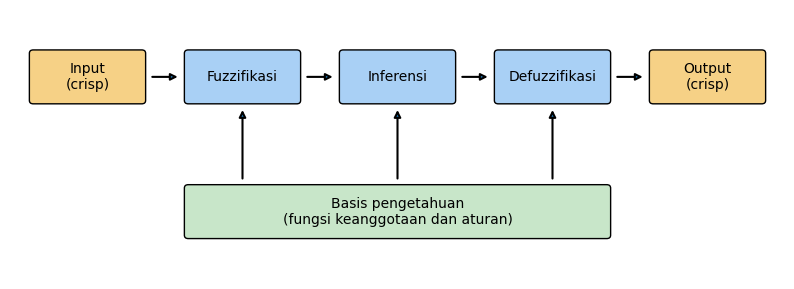

In [2]:
from matplotlib.patches import FancyBboxPatch


def draw_box(ax, x, y, width, text, color):
    """Gambar kotak berisi teks dengan titik tengah (x, y)."""
    box = FancyBboxPatch(
        (x - width / 2, y - 0.35), width, 0.7,
        boxstyle="round,pad=0.05", facecolor=color, edgecolor="black",
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha="center", va="center")


def draw_arrow(ax, start, end):
    """Gambar panah dari titik start ke titik end."""
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "-|>", "linewidth": 1.5})


fig, ax = plt.subplots(figsize=(10, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 4)
ax.axis("off")

# Baris atas: input, tiga tahap, lalu output.
stages = ["Input\n(crisp)", "Fuzzifikasi", "Inferensi", "Defuzzifikasi", "Output\n(crisp)"]
colors = ["#f6d186", "#a9d0f5", "#a9d0f5", "#a9d0f5", "#f6d186"]
centers = [1, 3, 5, 7, 9]
for x, text, color in zip(centers, stages, colors):
    draw_box(ax, x, 3, 1.4, text, color)
for x in centers[:-1]:
    draw_arrow(ax, (x + 0.8, 3), (x + 1.2, 3))

# Baris bawah: basis pengetahuan dipakai oleh ketiga tahap.
draw_box(ax, 5, 1, 5.4, "Basis pengetahuan\n(fungsi keanggotaan dan aturan)", "#c8e6c9")
for x in [3, 5, 7]:
    draw_arrow(ax, (x, 1.45), (x, 2.55))

plt.show()

Tabel berikut merinci isi setiap kotak pada diagram.

| Tahap | Yang dikerjakan | Hasil |
|---|---|---|
| Fuzzifikasi | Mengubah setiap input crisp menjadi derajat keanggotaan | $\mu$ setiap label, bernilai 0 sampai 1 |
| Inferensi | Menghitung setiap aturan IF-THEN | $\alpha$-predikat dan nilai $z$ setiap aturan |
| Defuzzifikasi | Menggabungkan hasil semua aturan | Satu output crisp |

Basis pengetahuan berisi hal yang ditetapkan oleh perancang sistem, terutama fungsi keanggotaan setiap variabel dan daftar aturan. Fuzzifikasi memakai fungsi keanggotaan input. Inferensi memakai daftar aturan. Defuzzifikasi memakai cara penggabungan yang dipilih perancang, yaitu centroid pada Mamdani (Notebook 02 bagian 2.6) dan rata-rata berbobot pada Sugeno (bagian 3.5).

Diagram ini berlaku untuk metode Mamdani maupun Sugeno. Kedua metode sama pada tahap fuzzifikasi. Perbedaannya ada pada bentuk aturan (bagian 3.4) dan cara defuzzifikasi (bagian 3.5).

Bagian 3.2 memberi contoh kasus. Bagian 3.3 sampai 3.5 mengerjakan kasus itu, satu bagian untuk satu tahap pada diagram.

---
## 3.2 Contoh kasus mesin cuci otomatis

Sebuah pabrik membuat mesin cuci otomatis berbasis fuzzy. Mesin ini mengatur **kecepatan putar** berdasarkan **banyaknya pakaian** dan **tingkat kekotoran**. Dua sensor pada mesin mengukur kedua nilai tersebut.

Spesifikasinya:

| Variabel | Peran | Simbol | Rentang | Keterangan |
|---|---|---|---|---|
| Banyaknya pakaian | input | $x$ | 0 sampai 100 | $\le 40$ termasuk sedikit, $\ge 80$ termasuk banyak |
| Tingkat kekotoran | input | $y$ | 0 sampai 100 | 0 sampai 40 rendah, 50 sedang, 60 sampai 100 tinggi |
| Kecepatan putar | output | $z$ | 500 sampai 1200 rpm | 500 rpm lambat, 1200 rpm cepat |

**Pertanyaan.** Berapa rpm kecepatan putar jika banyaknya pakaian bernilai 50 dan tingkat kekotoran bernilai 58?

Jika dicocokkan dengan diagram bagian 3.1, input sistem ini adalah $x = 50$ dan $y = 58$, dan output yang dicari adalah $z$ dalam rpm. Di dalam kode, $x$ disimpan pada variabel `clothes` dan $y$ pada variabel `dirt`.

Sel berikut menyimpan kedua input, lalu menggambar letaknya pada rentang masing-masing bersama keterangan dari tabel spesifikasi.

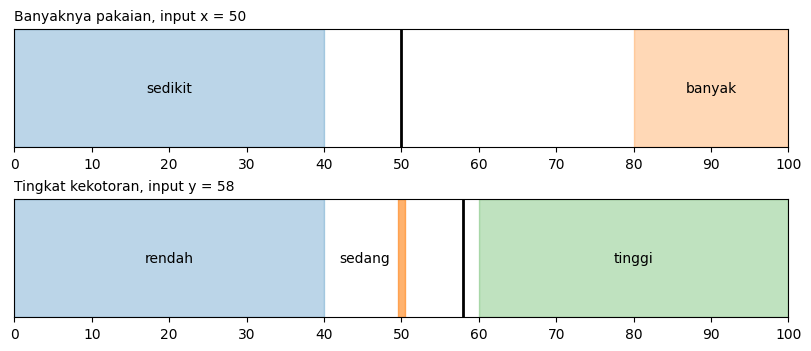

In [3]:
clothes = 50  # banyaknya pakaian (x)
dirt = 58     # tingkat kekotoran (y)

fig, axes = plt.subplots(2, 1, figsize=(8, 3.4), constrained_layout=True)

# Banyaknya pakaian: <= 40 sedikit, >= 80 banyak.
axes[0].axvspan(0, 40, color="tab:blue", alpha=0.3)
axes[0].axvspan(80, 100, color="tab:orange", alpha=0.3)
axes[0].text(20, 0.5, "sedikit", ha="center", va="center")
axes[0].text(90, 0.5, "banyak", ha="center", va="center")
axes[0].axvline(clothes, color="black", linewidth=2)
axes[0].set_title(f"Banyaknya pakaian, input x = {clothes}", loc="left", fontsize=10)

# Tingkat kekotoran: 0-40 rendah, 50 sedang, 60-100 tinggi.
axes[1].axvspan(0, 40, color="tab:blue", alpha=0.3)
axes[1].axvspan(49.5, 50.5, color="tab:orange", alpha=0.6)
axes[1].axvspan(60, 100, color="tab:green", alpha=0.3)
axes[1].text(20, 0.5, "rendah", ha="center", va="center")
axes[1].text(48.5, 0.5, "sedang", ha="right", va="center")
axes[1].text(80, 0.5, "tinggi", ha="center", va="center")
axes[1].axvline(dirt, color="black", linewidth=2)
axes[1].set_title(f"Tingkat kekotoran, input y = {dirt}", loc="left", fontsize=10)

for ax in axes:
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 10))
    ax.set_yticks([])

plt.show()

Garis hitam adalah input. Pakaian 50 berada di antara daerah sedikit dan daerah banyak. Kekotoran 58 berada di antara sedang dan tinggi. Spesifikasi tidak menyebut label untuk nilai di daerah kosong tersebut. Fuzzifikasi pada bagian 3.3 menentukan derajat setiap label di daerah itu.

---
## 3.3 Tahap 1: fuzzifikasi

Bagian 3.2 memberi dua input crisp, yaitu pakaian 50 dan kekotoran 58. Fuzzifikasi menghitung derajat keanggotaan ($\mu$) kedua angka itu pada setiap label. Derajat keanggotaan bernilai 0 sampai 1 dan menyatakan seberapa sesuai sebuah angka dengan sebuah label (Notebook 01 bagian 1.2).

Setiap label mempunyai fungsi keanggotaan. Fungsi ini termasuk basis pengetahuan, dan bentuknya diturunkan dari spesifikasi pada bagian 3.2. Kasus ini mempunyai tiga variabel, sehingga ada tiga kelompok fungsi keanggotaan.

### Fungsi bantu untuk menggambar

Ketiga variabel digambar dengan cara yang sama. Agar kodenya tidak ditulis tiga kali, sel berikut membuat fungsi `plot_membership`. Fungsi ini menggambar kurva setiap label. Jika `value` diisi, fungsi ini juga menandai derajat keanggotaan nilai tersebut.

In [4]:
def plot_membership(fuzzify, domain, xlabel, value=None):
    """Gambar kurva semua label milik satu variabel.

    fuzzify : fungsi yang menerima satu angka dan mengembalikan kamus {label: derajat}
    domain  : (batas kiri, batas kanan) sumbu mendatar
    value   : angka yang ditandai derajat keanggotaannya (boleh dikosongkan)
    """
    grid = np.linspace(domain[0], domain[1], 501)

    plt.figure(figsize=(8, 3))
    for label in fuzzify(domain[0]):
        curve = [fuzzify(x)[label] for x in grid]
        line = plt.plot(grid, curve, label=label)[0]
        if value is not None:
            degree = fuzzify(value)[label]
            plt.hlines(degree, domain[0], value, color=line.get_color(), linestyle="--", alpha=0.6)
            plt.scatter([value], [degree], color=line.get_color(), zorder=3)
            plt.annotate(f"{degree:.2f}", (value, degree), xytext=(6, 4), textcoords="offset points")
    if value is not None:
        plt.axvline(value, color="black", linestyle=":")

    plt.xlabel(xlabel)
    plt.ylabel("Derajat keanggotaan")
    plt.xlim(domain)
    plt.ylim(-0.05, 1.15)
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    plt.grid(alpha=0.2)
    plt.show()

### Variabel 1: banyaknya pakaian

Spesifikasi menyebut nilai $\le 40$ termasuk sedikit dan nilai $\ge 80$ termasuk banyak. Dari situ diperoleh dua label:

- **Sedikit** bernilai 1 sampai $x = 40$, lalu turun sampai 0 pada $x = 80$. Ini fungsi linier turun, `linear_down(x, 40, 80)`.
- **Banyak** bernilai 0 sampai $x = 40$, lalu naik sampai 1 pada $x = 80$. Ini fungsi linier naik, `linear_up(x, 40, 80)`.

$$
\mu_{\text{sedikit}}(x)=
\begin{cases}
1, & x\le 40\\[4pt]
\dfrac{80-x}{80-40}, & 40\le x\le 80\\[8pt]
0, & x\ge 80
\end{cases}
\qquad
\mu_{\text{banyak}}(x)=
\begin{cases}
0, & x\le 40\\[4pt]
\dfrac{x-40}{80-40}, & 40\le x\le 80\\[8pt]
1, & x\ge 80
\end{cases}
$$

Input $x = 50$ memenuhi $40\le x\le 80$, sehingga yang dipakai adalah baris tengah kedua rumus:

$$
\mu_{\text{sedikit}}(50)=\frac{80-50}{80-40}=\frac{30}{40}=0{,}75
\qquad
\mu_{\text{banyak}}(50)=\frac{50-40}{80-40}=\frac{10}{40}=0{,}25
$$

Sel berikut menulis kedua fungsi itu, menghitung derajat untuk `clothes`, lalu menggambarnya.

Derajat keanggotaan pakaian = 50 -> {'sedikit': 0.75, 'banyak': 0.25}


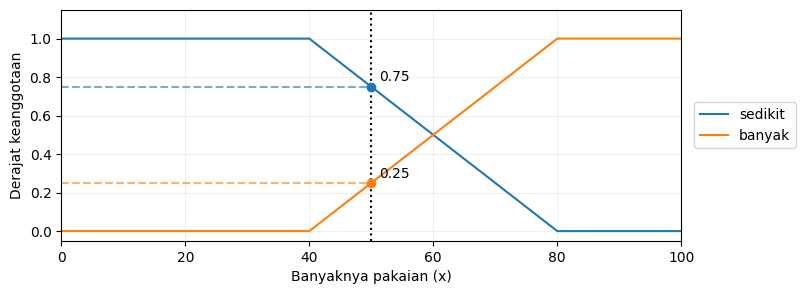

In [5]:
def fuzzify_clothes(x):
    """Hitung derajat keanggotaan banyaknya pakaian (0 sampai 100)."""
    return {
        "sedikit": linear_down(x, 40, 80),
        "banyak": linear_up(x, 40, 80),
    }


clothes_degrees = fuzzify_clothes(clothes)
print("Derajat keanggotaan pakaian =", clothes, "->", clothes_degrees)

plot_membership(fuzzify_clothes, domain=(0, 100), xlabel="Banyaknya pakaian (x)", value=clothes)

Hasil kode sama dengan hitungan tangan. Pakaian 50 termasuk Sedikit dengan derajat 0,75 dan termasuk Banyak dengan derajat 0,25. Satu angka dapat menjadi anggota dua label sekaligus.

Pada gambar, garis tegak di $x = 50$ memotong kurva Sedikit pada tinggi 0,75 dan kurva Banyak pada tinggi 0,25.

### Variabel 2: tingkat kekotoran

Spesifikasi menyebut 0 sampai 40 rendah, 50 sedang, dan 60 sampai 100 tinggi. Dari situ diperoleh tiga label:

- **Rendah** bernilai 1 sampai $y = 40$, lalu turun sampai 0 pada $y = 50$: `linear_down(y, 40, 50)`.
- **Sedang** bernilai 1 hanya pada $y = 50$, dan 0 pada $y \le 40$ atau $y \ge 60$. Ini fungsi segitiga, `triangular(y, 40, 50, 60)`.
- **Tinggi** bernilai 0 sampai $y = 50$, lalu naik sampai 1 pada $y = 60$: `linear_up(y, 50, 60)`.

$$
\mu_{\text{rendah}}(y)=
\begin{cases}
1, & y\le 40\\[4pt]
\dfrac{50-y}{50-40}, & 40\le y\le 50\\[8pt]
0, & y\ge 50
\end{cases}
\qquad
\mu_{\text{sedang}}(y)=
\begin{cases}
0, & y\le 40 \text{ atau } y\ge 60\\[4pt]
\dfrac{y-40}{50-40}, & 40\le y\le 50\\[8pt]
\dfrac{60-y}{60-50}, & 50\le y\le 60
\end{cases}
\qquad
\mu_{\text{tinggi}}(y)=
\begin{cases}
0, & y\le 50\\[4pt]
\dfrac{y-50}{60-50}, & 50\le y\le 60\\[8pt]
1, & y\ge 60
\end{cases}
$$

Untuk input $y = 58$:

- Rendah: $58\ge 50$, sehingga $\mu_{\text{rendah}}(58)=0$.
- Sedang: $50\le 58\le 60$, sehingga dipakai baris ketiga, yaitu garis turun segitiga.
- Tinggi: $50\le 58\le 60$, sehingga dipakai baris tengah.

$$
\mu_{\text{sedang}}(58)=\frac{60-58}{60-50}=\frac{2}{10}=0{,}2
\qquad
\mu_{\text{tinggi}}(58)=\frac{58-50}{60-50}=\frac{8}{10}=0{,}8
$$

Derajat keanggotaan kekotoran = 58 -> {'rendah': 0.0, 'sedang': 0.2, 'tinggi': 0.8}


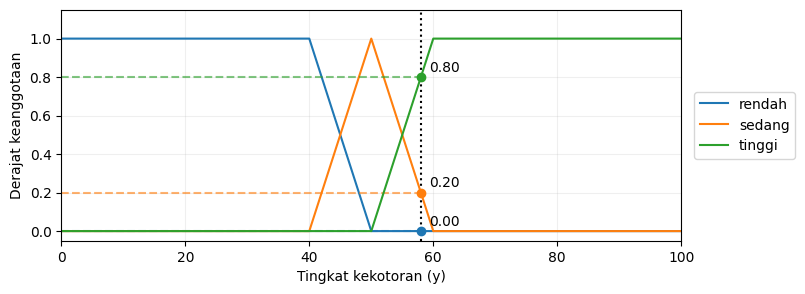

In [6]:
def fuzzify_dirt(y):
    """Hitung derajat keanggotaan tingkat kekotoran (0 sampai 100)."""
    return {
        "rendah": linear_down(y, 40, 50),
        "sedang": triangular(y, 40, 50, 60),
        "tinggi": linear_up(y, 50, 60),
    }


dirt_degrees = fuzzify_dirt(dirt)
print("Derajat keanggotaan kekotoran =", dirt, "->", dirt_degrees)

plot_membership(fuzzify_dirt, domain=(0, 100), xlabel="Tingkat kekotoran (y)", value=dirt)

Kekotoran 58 termasuk Sedang dengan derajat 0,2 dan termasuk Tinggi dengan derajat 0,8. Derajat Rendah bernilai 0, artinya 58 sama sekali tidak termasuk Rendah. Angka 58 lebih dekat ke 60 daripada ke 50, sehingga derajat Tinggi lebih besar daripada derajat Sedang.

### Variabel 3: kecepatan putar

Spesifikasi menyebut 500 rpm lambat dan 1200 rpm cepat. Dari situ diperoleh dua label:

- **Lambat** bernilai 1 sampai $z = 500$, lalu turun sampai 0 pada $z = 1200$: `linear_down(z, 500, 1200)`.
- **Cepat** bernilai 0 sampai $z = 500$, lalu naik sampai 1 pada $z = 1200$: `linear_up(z, 500, 1200)`.

$$
\mu_{\text{lambat}}(z)=
\begin{cases}
1, & z\le 500\\[4pt]
\dfrac{1200-z}{1200-500}, & 500\le z\le 1200\\[8pt]
0, & z\ge 1200
\end{cases}
\qquad
\mu_{\text{cepat}}(z)=
\begin{cases}
0, & z\le 500\\[4pt]
\dfrac{z-500}{1200-500}, & 500\le z\le 1200\\[8pt]
1, & z\ge 1200
\end{cases}
$$

Kecepatan putar adalah output, sehingga pada tahap ini belum ada angka yang difuzzifikasi. Pada metode Sugeno, fungsi keanggotaan output juga tidak ikut dalam perhitungan, karena hasil setiap aturan langsung berupa angka (bagian 3.4). Fungsi ini baru dipakai pada akhir bagian 3.5 untuk membaca seberapa lambat atau cepat putaran yang diperoleh.

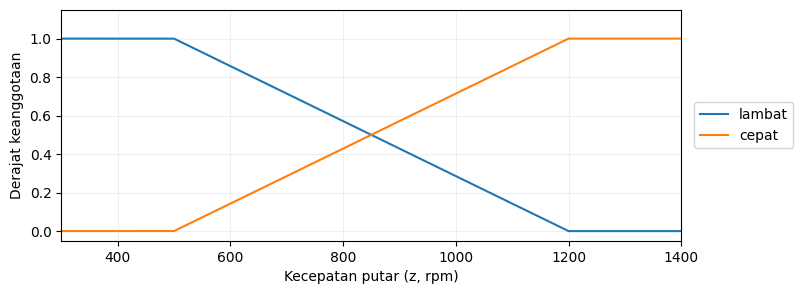

In [7]:
def fuzzify_speed(z):
    """Hitung derajat keanggotaan kecepatan putar (rpm)."""
    return {
        "lambat": linear_down(z, 500, 1200),
        "cepat": linear_up(z, 500, 1200),
    }


plot_membership(fuzzify_speed, domain=(300, 1400), xlabel="Kecepatan putar (z, rpm)")

### Hasil fuzzifikasi

Tahap 1 selesai. Dua input crisp sudah menjadi lima derajat keanggotaan:

| Input | Label | Derajat keanggotaan |
|---|---|---:|
| Pakaian $x = 50$ | Sedikit | 0,75 |
| | Banyak | 0,25 |
| Kekotoran $y = 58$ | Rendah | 0 |
| | Sedang | 0,2 |
| | Tinggi | 0,8 |

Kelima angka ini menjadi masukan tahap inferensi.

---
## 3.4 Tahap 2: inferensi

Fuzzifikasi menghasilkan lima derajat keanggotaan. Inferensi memakai kelima derajat itu untuk menghitung setiap aturan pada basis pengetahuan.

### Aturan

Dari pengujian prototipe mesin diperoleh enam aturan:

| Aturan | IF pakaian | AND kekotoran | THEN kecepatan putar (rpm) | Orde |
|---|---|---|---|---|
| R1 | Sedikit | Rendah | $z_1 = 500$ | nol |
| R2 | Sedikit | Sedang | $z_2 = 10y + 100$ | satu |
| R3 | Sedikit | Tinggi | $z_3 = 10y + 200$ | satu |
| R4 | Banyak | Rendah | $z_4 = 5x + 2y$ | satu |
| R5 | Banyak | Sedang | $z_5 = 5x + 4y + 100$ | satu |
| R6 | Banyak | Tinggi | $z_6 = 5x + 5y + 300$ | satu |

Setiap baris dibaca sebagai satu kalimat IF-THEN. Contohnya R2: IF pakaian Sedikit AND kekotoran Sedang THEN $z_2 = 10y + 100$.

Bagian setelah IF disebut **anteseden**. Bagian setelah THEN disebut **konsekuen**. Anteseden memakai label yang sudah difuzzifikasi pada bagian 3.3. Ada dua label pakaian dan tiga label kekotoran, sehingga ada $2\times 3 = 6$ pasangan label, dan setiap pasangan mempunyai satu aturan.

Pada metode Sugeno, konsekuen berisi konstanta atau persamaan linier dari input. Pada metode Mamdani (Notebook 02), konsekuen berisi label, misalnya kecepatan Lambat.

- **Sugeno orde nol**: konsekuen berupa konstanta. Contohnya R1, $z_1 = 500$.
- **Sugeno orde satu**: konsekuen berupa persamaan linier dari input. Contohnya R2 sampai R6.

Kedua bentuk itu dapat ditulis dengan satu rumus:

$$z_i = p_i\,x + q_i\,y + r_i$$

Pada orde nol, $p_i = q_i = 0$ sehingga yang tersisa hanya konstanta $r_i$. Sel berikut menyimpan keenam aturan dengan bentuk ini.

In [8]:
# Konsekuen setiap aturan: z = p * pakaian + q * kekotoran + r
rules = [
    {"aturan": "R1", "pakaian": "sedikit", "kekotoran": "rendah", "p": 0, "q": 0,  "r": 500},
    {"aturan": "R2", "pakaian": "sedikit", "kekotoran": "sedang", "p": 0, "q": 10, "r": 100},
    {"aturan": "R3", "pakaian": "sedikit", "kekotoran": "tinggi", "p": 0, "q": 10, "r": 200},
    {"aturan": "R4", "pakaian": "banyak",  "kekotoran": "rendah", "p": 5, "q": 2,  "r": 0},
    {"aturan": "R5", "pakaian": "banyak",  "kekotoran": "sedang", "p": 5, "q": 4,  "r": 100},
    {"aturan": "R6", "pakaian": "banyak",  "kekotoran": "tinggi", "p": 5, "q": 5,  "r": 300},
]
rule_names = [rule["aturan"] for rule in rules]

display(pd.DataFrame(rules))

,aturan,pakaian,kekotoran,p,q,r
0,R1,sedikit,rendah,0,0,500
1,R2,sedikit,sedang,0,10,100
2,R3,sedikit,tinggi,0,10,200
3,R4,banyak,rendah,5,2,0
4,R5,banyak,sedang,5,4,100
5,R6,banyak,tinggi,5,5,300


Kolom `pakaian` dan `kekotoran` adalah label pada anteseden. Kolom `p`, `q`, dan `r` adalah koefisien konsekuen. Baris R1 mempunyai `p = 0` dan `q = 0`, sesuai dengan orde nol.

Setiap aturan dihitung dalam dua langkah. Langkah 1 menghitung $\alpha$-predikat dari anteseden. Langkah 2 menghitung nilai $z$ dari konsekuen.

### Langkah 1: $\alpha$-predikat

$\alpha$-predikat menyatakan seberapa kuat sebuah aturan berlaku untuk input yang sedang dihitung. Notebook 01 dan 02 menyebutnya kekuatan aktivasi. Nilainya 0 sampai 1.

Anteseden setiap aturan berisi dua kondisi yang dihubungkan dengan AND. Operator AND memakai nilai terkecil (min) dari kedua derajat (Notebook 01 bagian 1.7):

$$\alpha_i=\min\big(\mu_{\text{pakaian}}(x),\ \mu_{\text{kekotoran}}(y)\big)$$

Derajatnya diambil dari hasil fuzzifikasi bagian 3.3:

$$
\begin{aligned}
\alpha_1&=\min(\mu_{\text{sedikit}}(50),\ \mu_{\text{rendah}}(58))=\min(0{,}75;\ 0)=0\\
\alpha_2&=\min(\mu_{\text{sedikit}}(50),\ \mu_{\text{sedang}}(58))=\min(0{,}75;\ 0{,}2)=0{,}2\\
\alpha_3&=\min(\mu_{\text{sedikit}}(50),\ \mu_{\text{tinggi}}(58))=\min(0{,}75;\ 0{,}8)=0{,}75\\
\alpha_4&=\min(\mu_{\text{banyak}}(50),\ \mu_{\text{rendah}}(58))=\min(0{,}25;\ 0)=0\\
\alpha_5&=\min(\mu_{\text{banyak}}(50),\ \mu_{\text{sedang}}(58))=\min(0{,}25;\ 0{,}2)=0{,}2\\
\alpha_6&=\min(\mu_{\text{banyak}}(50),\ \mu_{\text{tinggi}}(58))=\min(0{,}25;\ 0{,}8)=0{,}25
\end{aligned}
$$

Sel berikut menghitung hal yang sama untuk semua aturan, lalu menggambar kedua derajat dan $\alpha$-predikat setiap aturan.

,aturan,label pakaian,mu pakaian,label kekotoran,mu kekotoran,alpha
0,R1,sedikit,0.75,rendah,0.0,0.00
1,R2,sedikit,0.75,sedang,0.2,0.20
2,R3,sedikit,0.75,tinggi,0.8,0.75
3,R4,banyak,0.25,rendah,0.0,0.00
4,R5,banyak,0.25,sedang,0.2,0.20
5,R6,banyak,0.25,tinggi,0.8,0.25


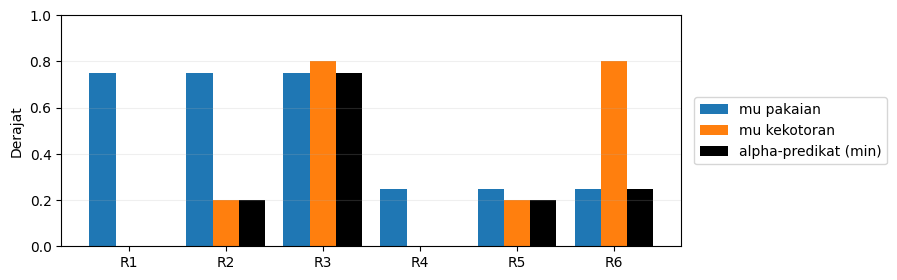

In [9]:
alphas = []
alpha_rows = []
for rule in rules:
    mu_clothes = clothes_degrees[rule["pakaian"]]
    mu_dirt = dirt_degrees[rule["kekotoran"]]
    alpha = min(mu_clothes, mu_dirt)  # AND = min
    alphas.append(alpha)
    alpha_rows.append({
        "aturan": rule["aturan"],
        "label pakaian": rule["pakaian"],
        "mu pakaian": mu_clothes,
        "label kekotoran": rule["kekotoran"],
        "mu kekotoran": mu_dirt,
        "alpha": alpha,
    })
alpha_table = pd.DataFrame(alpha_rows)
display(alpha_table.round(4))

positions = np.arange(len(rules))
plt.figure(figsize=(8, 3))
plt.bar(positions - 0.27, alpha_table["mu pakaian"], width=0.27, label="mu pakaian")
plt.bar(positions, alpha_table["mu kekotoran"], width=0.27, label="mu kekotoran")
plt.bar(positions + 0.27, alphas, width=0.27, color="black", label="alpha-predikat (min)")
plt.xticks(positions, rule_names)
plt.ylabel("Derajat")
plt.ylim(0, 1)
plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.grid(axis="y", alpha=0.2)
plt.show()

Pada setiap aturan, batang hitam ($\alpha$-predikat) sama tinggi dengan batang terpendek di sebelah kirinya.

R1 dan R4 mempunyai $\alpha = 0$ karena keduanya memakai label Rendah, dan derajat Rendah untuk kekotoran 58 adalah 0. Aturan dengan $\alpha = 0$ disebut tidak aktif. Empat aturan lainnya aktif. R3 mempunyai $\alpha$ terbesar, yaitu 0,75.

### Langkah 2: nilai $z$

Langkah 1 memberi $\alpha$-predikat, yaitu seberapa kuat aturan berlaku. Langkah 2 menghitung nilai $z$, yaitu kecepatan putar menurut aturan itu. Caranya: masukkan $x = 50$ dan $y = 58$ ke konsekuen.

$$
\begin{aligned}
z_1&=500\\
z_2&=10(58)+100=680\\
z_3&=10(58)+200=780\\
z_4&=5(50)+2(58)=366\\
z_5&=5(50)+4(58)+100=582\\
z_6&=5(50)+5(58)+300=840
\end{aligned}
$$

Nilai $z$ mempunyai satuan rpm. Nilai ini bukan derajat keanggotaan, sehingga tidak dibatasi 0 sampai 1.

Sel berikut menghitung $z$ dengan rumus $z = p\,x + q\,y + r$, lalu menggambar hasil inferensi. Setiap aturan digambar sebagai satu garis tegak: letaknya pada sumbu mendatar adalah $z$, dan tingginya adalah $\alpha$-predikat.

R1: z = 0 * 50 + 0 * 58 + 500 = 500
R2: z = 0 * 50 + 10 * 58 + 100 = 680
R3: z = 0 * 50 + 10 * 58 + 200 = 780
R4: z = 5 * 50 + 2 * 58 + 0 = 366
R5: z = 5 * 50 + 4 * 58 + 100 = 582
R6: z = 5 * 50 + 5 * 58 + 300 = 840


,aturan,alpha,z (rpm)
0,R1,0.00,500
1,R2,0.20,680
2,R3,0.75,780
3,R4,0.00,366
4,R5,0.20,582
5,R6,0.25,840


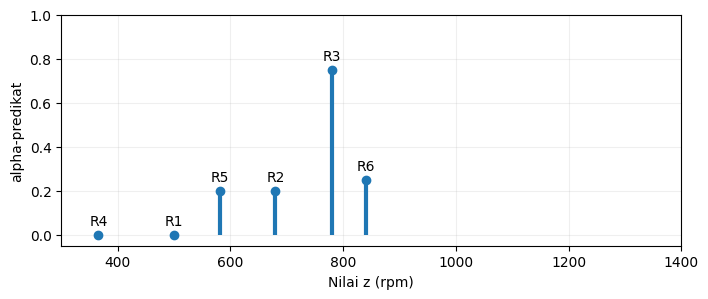

In [10]:
z_values = []
for rule in rules:
    z = rule["p"] * clothes + rule["q"] * dirt + rule["r"]
    z_values.append(z)
    print(f'{rule["aturan"]}: z = {rule["p"]} * {clothes} + {rule["q"]} * {dirt} + {rule["r"]} = {z}')

inference_table = pd.DataFrame({"aturan": rule_names, "alpha": alphas, "z (rpm)": z_values})
display(inference_table.round(4))


def plot_rule_outputs(z_values, alphas, z_star=None):
    """Gambar hasil setiap aturan: letak = z, tinggi = alpha-predikat."""
    plt.figure(figsize=(8, 3))
    plt.vlines(z_values, 0, alphas, linewidth=3)
    plt.scatter(z_values, alphas, zorder=3)
    for name, z, alpha in zip(rule_names, z_values, alphas):
        plt.annotate(name, (z, alpha), xytext=(0, 7), textcoords="offset points", ha="center")
    if z_star is not None:
        plt.axvline(z_star, color="red", linestyle="--", label=f"z* = {z_star:.2f} rpm")
        plt.legend(loc="upper left")
    plt.xlabel("Nilai z (rpm)")
    plt.ylabel("alpha-predikat")
    plt.xlim(300, 1400)
    plt.ylim(-0.05, 1)
    plt.grid(alpha=0.2)
    plt.show()


plot_rule_outputs(z_values, alphas)

Nilai $z$ dihitung untuk semua aturan, termasuk R1 dan R4 yang tidak aktif. Pada gambar, R1 dan R4 hanya berupa titik pada tinggi 0.

Tahap 2 selesai. Setiap aturan sekarang mempunyai sepasang angka:

| Aturan | $\alpha$-predikat | $z$ (rpm) |
|---|---:|---:|
| R1 | 0 | 500 |
| R2 | 0,2 | 680 |
| R3 | 0,75 | 780 |
| R4 | 0 | 366 |
| R5 | 0,2 | 582 |
| R6 | 0,25 | 840 |

Enam pasang angka ini menjadi masukan tahap defuzzifikasi.

---
## 3.5 Tahap 3: defuzzifikasi

Inferensi menghasilkan enam pasang $(\alpha_i, z_i)$. Mesin cuci membutuhkan satu angka kecepatan putar. Defuzzifikasi menggabungkan keenam pasang itu menjadi satu output crisp $z^*$.

Metode Sugeno memakai **rata-rata berbobot**. Setiap $z_i$ dikalikan dengan $\alpha_i$, hasilnya dijumlahkan, lalu dibagi dengan jumlah semua $\alpha_i$:

$$z^*=\frac{\sum_{i}\alpha_i\,z_i}{\sum_{i}\alpha_i}$$

Dengan angka dari bagian 3.4:

$$
z^*=\frac{(0)(500)+(0{,}2)(680)+(0{,}75)(780)+(0)(366)+(0{,}2)(582)+(0{,}25)(840)}{0+0{,}2+0{,}75+0+0{,}2+0{,}25}
$$

$$
z^*=\frac{0+136+585+0+116{,}4+210}{1{,}4}=\frac{1047{,}4}{1{,}4}=748{,}14\text{ rpm}
$$

Sel berikut mengerjakan hitungan yang sama.

,aturan,alpha,z (rpm),alpha * z
0,R1,0.00,500,0.0
1,R2,0.20,680,136.0
2,R3,0.75,780,585.0
3,R4,0.00,366,0.0
4,R5,0.20,582,116.4
5,R6,0.25,840,210.0


Jumlah alpha * z = 1047.40
Jumlah alpha     = 1.40
z* = 1047.40 / 1.40 = 748.14 rpm


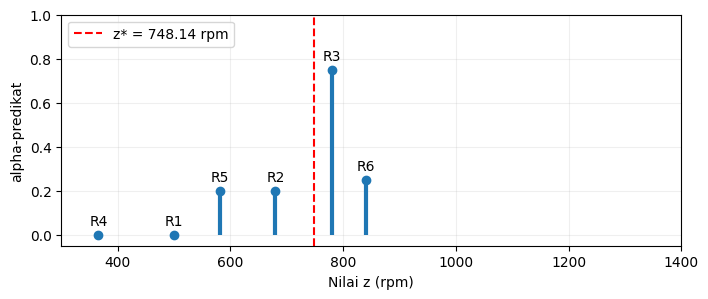

In [11]:
products = [alpha * z for alpha, z in zip(alphas, z_values)]

numerator = sum(products)    # jumlah alpha * z
denominator = sum(alphas)    # jumlah alpha
z_star = numerator / denominator

display(pd.DataFrame({
    "aturan": rule_names,
    "alpha": alphas,
    "z (rpm)": z_values,
    "alpha * z": products,
}).round(4))
print(f"Jumlah alpha * z = {numerator:.2f}")
print(f"Jumlah alpha     = {denominator:.2f}")
print(f"z* = {numerator:.2f} / {denominator:.2f} = {z_star:.2f} rpm")

plot_rule_outputs(z_values, alphas, z_star=z_star)

Garis merah putus-putus adalah $z^*$. Ada tiga hal yang dapat dibaca dari gambar:

- $z^*$ berada di antara nilai $z$ terkecil dan terbesar milik aturan yang aktif: $582\le 748{,}14\le 840$. Rata-rata berbobot selalu seperti ini.
- Semakin besar $\alpha$ sebuah aturan, semakin dekat $z^*$ ke nilai $z$ aturan itu. R3 mempunyai $\alpha$ terbesar (0,75), dan $z^* = 748{,}14$ dekat dengan $z_3 = 780$.
- R1 dan R4 tidak berpengaruh karena $\alpha$-nya 0. Nilai $z_4 = 366$ tidak mengubah hasil.

Jumlah $\alpha$ tidak harus 1, karena rumusnya membagi dengan jumlah $\alpha$. Jika semua $\alpha$ bernilai 0, pembagian tidak dapat dilakukan. Pada kasus ini hal itu tidak terjadi: untuk setiap $x$ ada label pakaian yang derajatnya lebih dari 0, dan untuk setiap $y$ ada label kekotoran yang derajatnya lebih dari 0, sehingga selalu ada aturan yang aktif.

**Catatan tentang materi rujukan.** Slide rujukan kasus ini menulis hasil akhir 733,85 rpm. Pada slide itu $z_2$ dihitung 680 pada tahap inferensi, tetapi ditulis 580 pada rumus defuzzifikasi. Dengan $z_2 = 680$, hasilnya 748,14 rpm seperti di atas.

### Membaca hasil

Fungsi keanggotaan kecepatan putar dari bagian 3.3 sekarang dipakai untuk membaca $z^*$:

$$
\mu_{\text{lambat}}(748{,}14)=\frac{1200-748{,}14}{1200-500}=0{,}65
\qquad
\mu_{\text{cepat}}(748{,}14)=\frac{748{,}14-500}{1200-500}=0{,}35
$$

Derajat keanggotaan z* -> {'lambat': 0.6455102040816325, 'cepat': 0.3544897959183675}


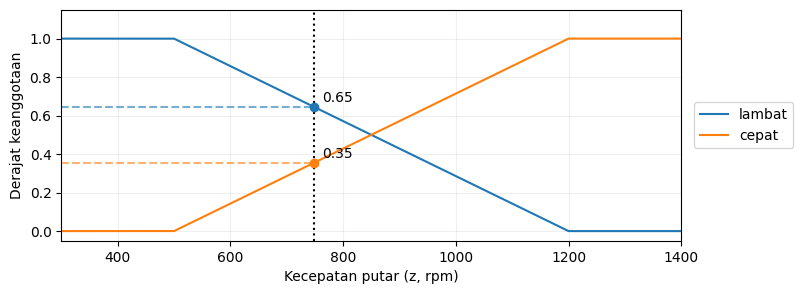

In [12]:
print("Derajat keanggotaan z* ->", fuzzify_speed(z_star))

plot_membership(fuzzify_speed, domain=(300, 1400), xlabel="Kecepatan putar (z, rpm)", value=z_star)

Putaran 748,14 rpm termasuk Lambat dengan derajat 0,65 dan termasuk Cepat dengan derajat 0,35.

**Kesimpulan.** Jika banyaknya pakaian bernilai 50 dan tingkat kekotoran bernilai 58, kecepatan putar mesin cuci adalah 748,14 rpm, dibulatkan menjadi 748 rpm.

Ringkasan ketiga tahap untuk kasus ini:

| Tahap | Masukan | Hasil |
|---|---|---|
| Fuzzifikasi | $x = 50$, $y = 58$ | Sedikit 0,75; Banyak 0,25; Rendah 0; Sedang 0,2; Tinggi 0,8 |
| Inferensi | lima derajat di atas dan enam aturan | $\alpha$ = 0; 0,2; 0,75; 0; 0,2; 0,25 dan $z$ = 500; 680; 780; 366; 582; 840 |
| Defuzzifikasi | enam pasang $(\alpha, z)$ | $z^* = 1047{,}4 / 1{,}4 = 748{,}14$ rpm |

---
## 3.6 Seluruh tahap dalam satu fungsi

Bagian 3.3 sampai 3.5 mengerjakan ketiga tahap satu per satu untuk satu pasang input. Sel berikut menggabungkan ketiganya ke dalam fungsi `washing_speed`, sehingga input lain dapat dihitung dengan satu baris. Isi fungsi ini sama dengan kode pada bagian sebelumnya.

In [13]:
def washing_speed(clothes, dirt):
    """Hitung kecepatan putar mesin cuci (rpm) dengan metode Sugeno."""
    # Tahap 1: fuzzifikasi
    clothes_degrees = fuzzify_clothes(clothes)
    dirt_degrees = fuzzify_dirt(dirt)

    # Tahap 2: inferensi (alpha-predikat dan nilai z setiap aturan)
    numerator = 0.0
    denominator = 0.0
    for rule in rules:
        alpha = min(clothes_degrees[rule["pakaian"]], dirt_degrees[rule["kekotoran"]])
        z = rule["p"] * clothes + rule["q"] * dirt + rule["r"]
        numerator += alpha * z
        denominator += alpha

    # Tahap 3: defuzzifikasi dengan rata-rata berbobot
    return numerator / denominator


print(f"Pakaian 50, kekotoran 58 -> {washing_speed(50, 58):.2f} rpm")

trial_rows = []
for trial_clothes, trial_dirt in [(20, 30), (50, 40), (50, 58), (70, 0), (90, 55), (100, 100)]:
    trial_rows.append({
        "pakaian": trial_clothes,
        "kekotoran": trial_dirt,
        "kecepatan putar (rpm)": washing_speed(trial_clothes, trial_dirt),
    })
display(pd.DataFrame(trial_rows).round(2))

Pakaian 50, kekotoran 58 -> 748.14 rpm


,pakaian,kekotoran,kecepatan putar (rpm)
0,20,30,500.00
1,50,40,457.50
2,50,58,748.14
3,70,0,387.50
4,90,55,897.50
5,100,100,1300.00


Fungsi ini memberi 748,14 rpm untuk input contoh, sama dengan hasil bagian 3.5.

Pada tabel ada keluaran di bawah 500 rpm dan di atas 1200 rpm, padahal spesifikasi bagian 3.2 menyebut kecepatan putar 500 sampai 1200 rpm. Untuk melihat di mana hal itu terjadi, sel berikut menghitung keluaran untuk semua pasangan input dari 0 sampai 100 dan menggambarnya sebagai peta warna.

Keluaran terkecil: 387.5 rpm
Keluaran terbesar: 1300.0 rpm
Bagian domain dengan keluaran di bawah 500 rpm: 22%
Bagian domain dengan keluaran di atas 1200 rpm: 2%


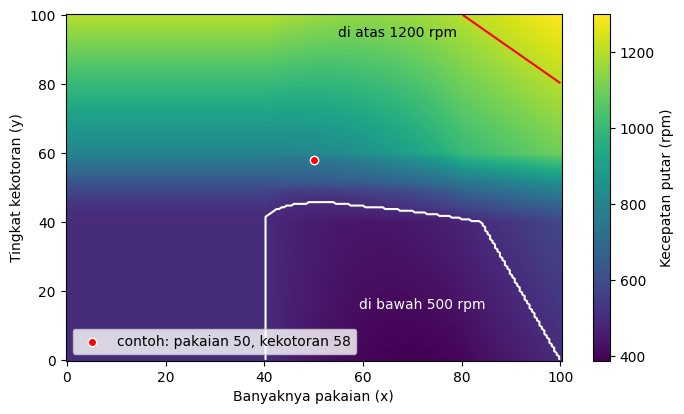

In [14]:
clothes_grid = np.linspace(0, 100, 201)  # 0; 0,5; 1; ...; 100
dirt_grid = np.linspace(0, 100, 201)
speed_map = np.array([
    [washing_speed(x, y) for x in clothes_grid]
    for y in dirt_grid
])
below_spec = (speed_map < 500).astype(float)   # 1 jika di bawah 500 rpm, 0 jika tidak
above_spec = (speed_map > 1200).astype(float)  # 1 jika di atas 1200 rpm, 0 jika tidak

print(f"Keluaran terkecil: {speed_map.min():.1f} rpm")
print(f"Keluaran terbesar: {speed_map.max():.1f} rpm")
print(f"Bagian domain dengan keluaran di bawah 500 rpm: {below_spec.mean():.0%}")
print(f"Bagian domain dengan keluaran di atas 1200 rpm: {above_spec.mean():.0%}")

plt.figure(figsize=(8, 4.5))
mesh = plt.pcolormesh(clothes_grid, dirt_grid, speed_map, shading="auto", cmap="viridis")
plt.colorbar(mesh, label="Kecepatan putar (rpm)")

# Garis batas daerah yang keluarannya di luar spesifikasi 500-1200 rpm.
plt.contour(clothes_grid, dirt_grid, below_spec, levels=[0.5], colors="white")
plt.contour(clothes_grid, dirt_grid, above_spec, levels=[0.5], colors="red")
plt.text(72, 15, "di bawah 500 rpm", color="white", ha="center")
plt.text(79, 97, "di atas 1200 rpm", color="black", ha="right", va="top")

plt.scatter([clothes], [dirt], color="red", edgecolor="white", zorder=3, label="contoh: pakaian 50, kekotoran 58")
plt.xlabel("Banyaknya pakaian (x)")
plt.ylabel("Tingkat kekotoran (y)")
plt.legend(loc="lower left")
plt.show()

Garis putih mengelilingi daerah dengan keluaran di bawah 500 rpm, yaitu sekitar 22% dari seluruh pasangan input. Garis merah di sudut kanan atas membatasi daerah dengan keluaran di atas 1200 rpm, sekitar 2%. Keluaran terkecil adalah 387,5 rpm (pakaian 70, kekotoran 0) dan keluaran terbesar adalah 1300 rpm (pakaian 100, kekotoran 100).

Penyebabnya ada pada konsekuen. Rata-rata berbobot selalu berada di antara nilai $z$ aturan yang aktif (bagian 3.5), sehingga keluaran di luar spesifikasi hanya muncul jika ada nilai $z$ yang di luar spesifikasi. Contohnya, R4 memberi $z_4 = 5(70)+2(0) = 350$ rpm untuk pakaian 70 dan kekotoran 0, dan R6 memberi $z_6 = 5(100)+5(100)+300 = 1300$ rpm untuk kedua input 100.

Satu contoh hitungan tidak memperlihatkan hal ini. Model fuzzy perlu dicoba pada seluruh domain input sebelum dipakai.

---
## Latihan Soal

Ketiga soal memakai kasus mesin cuci pada notebook ini. Kerjakan hitungan tangan lebih dahulu, lalu periksa dengan Python. Tulis jawaban pada sel kosong; tambahkan sel Markdown atau kode jika diperlukan.

### Soal 1 - Menghitung tiga tahap untuk input lain

Hitung kecepatan putar untuk banyaknya pakaian **70** dan tingkat kekotoran **45**.

1. Hitung derajat keanggotaan kedua input pada setiap label.
2. Hitung $\alpha$-predikat keenam aturan, termasuk yang bernilai 0.
3. Hitung nilai $z$ keenam aturan.
4. Hitung $\sum\alpha_i z_i$, $\sum\alpha_i$, dan $z^*$.
5. Periksa hasilnya dengan `washing_speed(70, 45)`.

<details>
<summary>Klik untuk melihat hint</summary>

Pakaian 70 berada di antara 40 dan 80, dan kekotoran 45 berada di antara 40 dan 50. Derajat Tinggi bernilai 0, sehingga R3 dan R6 tidak aktif. Jumlah $\alpha$ adalah 1,5 dan hasil akhirnya 531,67 rpm.

</details>

### Soal 2 - Pengaruh tingkat kekotoran

Tetapkan banyaknya pakaian pada **50**. Hitung kecepatan putar untuk tingkat kekotoran 40, 42, 44, dan seterusnya sampai 60, lalu gambar grafiknya.

1. Pada tingkat kekotoran berapa keluaran pertama kali mencapai 500 rpm atau lebih?
2. Aturan mana yang aktif pada kekotoran 40, dan aturan mana yang aktif pada kekotoran 60?
3. Jelaskan mengapa keluaran naik ketika tingkat kekotoran naik.

<details>
<summary>Klik untuk melihat hint</summary>

Panggil `washing_speed(50, y)` di dalam perulangan `for y in range(40, 61, 2)`. Pada kekotoran 40 derajat Rendah bernilai 1, dan pada kekotoran 60 derajat Tinggi bernilai 1. Bandingkan nilai $z$ aturan yang aktif pada kedua keadaan itu.

</details>

### Soal 3 - Keluaran di bawah spesifikasi

Bagian 3.6 menunjukkan bahwa pakaian **70** dan kekotoran **0** menghasilkan 387,5 rpm, di bawah batas 500 rpm.

1. Hitung $\alpha$-predikat dan nilai $z$ keenam aturan untuk input itu. Aturan mana yang membuat keluaran turun di bawah 500 rpm?
2. Usulkan konsekuen baru untuk aturan tersebut agar keluarannya tidak kurang dari 500 rpm.
3. Ubah daftar `rules`, gambar ulang peta warna bagian 3.6, lalu periksa keluaran terkecilnya. Jika masih di bawah 500 rpm, cari aturan lain yang nilai $z$-nya dapat kurang dari 500.

<details>
<summary>Klik untuk melihat hint</summary>

Untuk pakaian 70 dan kekotoran 0 hanya R1 dan R4 yang aktif, dan $z_1 = 500$. Periksa nilai $z_4$. Saat menguji usulan, ingat bahwa sebuah aturan hanya berpengaruh pada input yang membuat $\alpha$-nya lebih dari 0, misalnya R4 hanya aktif untuk $x > 40$ dan $y < 50$.

</details>